### data transformation

In [0]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime

In [0]:
from pyspark.sql import functions as F
from itertools import chain

data = spark.table('workspace.default.gss_2000')

#set datetime columns
data = data.withColumn("year", F.to_date(F.col("year")))
data = data.withColumn("cohort", F.to_date(F.col("cohort")))

In [0]:
df = data
df.head(20)

[Row(year=datetime.date(2000, 1, 1), age=26, cohort=datetime.date(1974, 1, 1), sex=1, race=1, ethnic=None, hispanic=1, marital=5, region=3, educ=16, degree=3, dipged=None, income=None, coninc=None, uscitzn=None, wrkstat=1, evwork=None, wrkslf=2, wrkslffam=None, whatslf2=None, indus10=6670, wrkgovt1=None, wrkgovt2=None, occ10=2900, prestg10=43, sei10=57.3, rincome=8, conrinc=9300.0, localnum=4, wksub=1, wksubs=3, wksup=2, wksups=None, paeduc=16, maeduc=16, happy=2, satjob=1, class=3, satfin=3, finalter=3, finrela=4, joblose=4, jobfind=2, getahead=3, richwork=None, unemp=None, union=None, parsol=None, goodlife=None),
 Row(year=datetime.date(2000, 1, 1), age=48, cohort=datetime.date(1952, 1, 1), sex=2, race=1, ethnic=22, hispanic=3, marital=3, region=3, educ=15, degree=1, dipged=None, income=8, coninc=9300.0, uscitzn=None, wrkstat=1, evwork=None, wrkslf=2, wrkslffam=None, whatslf2=None, indus10=9370, wrkgovt1=None, wrkgovt2=None, occ10=5700, prestg10=47, sei10=38.8, rincome=8, conrinc=930

In [0]:
gss_codebook = {
    'sex': {1: 'Male', 2: 'Female'},
    'race': {1: 'White', 2: 'Black', 3: 'Other'},
    'hispanic': {1: 'Not Hispanic', 2: 'Mexican', 3: 'Puerto Rican', 4: 'Cuban', 5: 'Other Spanish'},
    'marital': {1: 'Married', 2: 'Widowed', 3: 'Divorced', 4: 'Separated', 5: 'Never married'},
    'region': {
        1: 'New England', 2: 'Middle Atlantic', 3: 'East North Central', 
        4: 'West North Central', 5: 'South Atlantic', 6: 'East South Central', 
        7: 'West South Central', 8: 'Mountain', 9: 'Pacific'
    },
    'degree': {0: 'Lt High School', 1: 'High School', 2: 'Junior College', 3: 'Bachelor', 4: 'Graduate'},
    'dipged': {1: 'High School Diploma', 2: 'GED', 3: 'Other'},
    'wrkstat': {
        1: 'Working Full Time', 2: 'Working Part Time', 3: 'With a Job, But Not at Work', 
        4: 'Unemployed, Laid Off', 5: 'Retired', 6: 'In School', 7: 'Keeping House', 8: 'Other'
    },
    'evwork': {1: 'Yes', 2: 'No'},
    'wrkslf': {1: 'Self-Employed', 2: 'Someone Else'},
    'wrkslffam': {1: 'Self-Employed', 2: 'Someone Else'},
    'wrkgovt1': {1: 'Government', 2: 'Private'},
    'wrkgovt2': {1: 'Government', 2: 'Private'},
    'uscitzn': {1: 'U.S. Citizen', 2: 'Not a U.S. Citizen'},
    'happy': {1: 'Very Happy', 2: 'Pretty Happy', 3: 'Not Too Happy'},
    'satjob': {1: 'Very Satisfied', 2: 'Mod. Satisfied', 3: 'A Little Dissat', 4: 'Very Dissat'},
    'class': {1: 'Lower Class', 2: 'Working Class', 3: 'Middle Class', 4: 'Upper Class'},
    'satfin': {1: 'Satisfied', 2: 'More or Less', 3: 'Not at All'},
    'finalter': {1: 'Better', 2: 'Worse', 3: 'Stayed Same'},
    'finrela': {1: 'Far Below Average', 2: 'Below Average', 3: 'Average', 4: 'Above Average', 5: 'Far Above Average'},
    'joblose': {1: 'Very Likely', 2: 'Fairly Likely', 3: 'Not Too Likely', 4: 'Not at All Likely'},
    'jobfind': {1: 'Very Easy', 2: 'Somewhat Easy', 3: 'Not Easy at All'},
    'getahead': {1: 'Hard Work', 2: 'Luck or Help', 3: 'Both'},
    'richwork': {1: 'Continue Working', 2: 'Stop Working'},
    'unemp': {1: 'Yes', 2: 'No'},
    'union': {1: 'Does Not Belong', 2: 'Respondent Belongs', 3: 'Spouse Belongs', 4: 'Both Belong'},
    'parsol': {1: 'Much Better', 2: 'Somewhat Better', 3: 'About the Same', 4: 'Somewhat Worse', 5: 'Much Worse'},
    'goodlife': {1: 'Strongly Agree', 2: 'Agree', 3: 'Neither', 4: 'Disagree', 5: 'Strongly Disagree'},
    'wksub': {1: 'Yes', 2: 'No'},
    'wksubs': {1: 'Yes', 2: 'No'},
    'wksup': {1: 'Yes', 2: 'No'},
    'wksups': {1: 'Yes', 2: 'No'},
    'income': {
        1: '<$1000', 2: '$1000-2999', 3: '$3000-3999', 4: '$4000-4999', 5: '$5000-5999',
        6: '$6000-6999', 7: '$7000-7999', 8: '$8000-9999', 9: '$10000-14999', 
        10: '$15000-19999', 11: '$20000-24999', 12: '$25000+'
    },
    'rincome': {
        1: '<$1000', 2: '$1000-2999', 3: '$3000-3999', 4: '$4000-4999', 5: '$5000-5999',
        6: '$6000-6999', 7: '$7000-7999', 8: '$8000-9999', 9: '$10000-14999', 
        10: '$15000-19999', 11: '$20000-24999', 12: '$25000+'
    }
}

In [0]:
for col_name, mapping in gss_codebook.items():
    if col_name in df.columns:
        #Create the mapping expression
        map_col = F.create_map([F.lit(x) for x in chain(*mapping.items())])
        
        df = df.withColumn(col_name, map_col[F.col(col_name).cast("int")]) #cast column to int, then perform mapping lookup

df.printSchema()
df.show(10, truncate=False)

root
 |-- year: date (nullable = true)
 |-- age: long (nullable = true)
 |-- cohort: date (nullable = true)
 |-- sex: string (nullable = true)
 |-- race: string (nullable = true)
 |-- ethnic: long (nullable = true)
 |-- hispanic: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- region: string (nullable = true)
 |-- educ: long (nullable = true)
 |-- degree: string (nullable = true)
 |-- dipged: string (nullable = true)
 |-- income: string (nullable = true)
 |-- coninc: double (nullable = true)
 |-- uscitzn: string (nullable = true)
 |-- wrkstat: string (nullable = true)
 |-- evwork: string (nullable = true)
 |-- wrkslf: string (nullable = true)
 |-- wrkslffam: string (nullable = true)
 |-- whatslf2: long (nullable = true)
 |-- indus10: long (nullable = true)
 |-- wrkgovt1: string (nullable = true)
 |-- wrkgovt2: string (nullable = true)
 |-- occ10: long (nullable = true)
 |-- prestg10: long (nullable = true)
 |-- sei10: double (nullable = true)
 |-- rincome: string (

In [0]:
def apply_gss_industries(df, input_col):

  return df.withColumn(
        "industry_name",
        F.when(F.col(input_col).between(170, 290), "Agriculture, Forestry, Fishing, & Hunting")
        .when(F.col(input_col).between(370, 490), "Mining")
        .when(F.col(input_col).between(570, 690), "Utilities")
        .when(F.col(input_col) == 770, "Construction")
        .when(F.col(input_col).between(1070, 3990), "Manufacturing")
        .when(F.col(input_col).between(4070, 4590), "Wholesale Trade")
        .when(F.col(input_col).between(4670, 5790), "Retail Trade")
        .when(F.col(input_col).between(6070, 6390), "Transportation & Warehousing")
        .when(F.col(input_col).between(6470, 6790), "Information")
        .when(F.col(input_col).between(6870, 7190), "Finance & Insurance")
        .when(F.col(input_col).between(7270, 7490), "Real Estate & Rental/Leasing")
        .when(F.col(input_col).between(7570, 7790), "Professional, Scientific, & Tech Services")
        .when(F.col(input_col).between(7860, 7890), "Management of Companies")
        .when(F.col(input_col).between(7970, 8290), "Admin, Support, & Waste Mgmt")
        .when(F.col(input_col).between(8370, 8470), "Educational Services")
        .when(F.col(input_col).between(8560, 8690), "Health Care & Social Assistance")
        .when(F.col(input_col).between(8770, 9290), "Arts, Entertainment, & Food Services")
        .when(F.col(input_col).between(9370, 9590), "Other Services (excl. Public Admin)")
        .when(F.col(input_col).between(9670, 9870), "Public Administration")
        .when(F.col(input_col) == 9890, "Armed Forces")
        .otherwise("Unclassified/No Response")
    )

def apply_industry_groups(df, input_col):
  return df.withColumn(
    "industry_group",
    F.when(F.col("industry_name").isin(
        "Agriculture, Forestry, Fishing, & Hunting",
        "Mining",
        "Construction",
        "Manufacturing"
    ), "Primary & Manufacturing Production")
    .when(F.col("industry_name").isin(
          "Utilities"),
          "Energy & Utilities")
    .when(F.col("industry_name").isin(
        "Wholesale Trade",
        "Retail Trade",
        "Transportation & Warehousing"
    ), "Trade & Logistics")
    .when(F.col("industry_name").isin(
        "Information",
        "Finance & Insurance",
        "Real Estate & Rental/Leasing"
    ), "Real Estate & Financial Services")
    .when(F.col("industry_name").isin(
        "Professional, Scientific, & Tech Services",
        "Management of Companies",
        "Information",
    ), "Professional & Technical Services")
    .when(F.col("industry_name").isin(
      "Admin, Support, & Waste Mgmt"),
          "Business Support & Facility Services")
    .when(F.col("industry_name").isin(
        "Educational Services",
        "Health Care & Social Assistance"
    ), "Education & Health Services")
    .when(F.col("industry_name").isin(
        "Arts, Entertainment, & Food Services",
        "Other Services (excl. Public Admin)"
    ), "Leisure, Hospitality & Miscellaneous Services")
    .when(F.col("industry_name").isin(
        "Public Administration",
        "Armed Forces"
    ), "Government & Defense")
    .otherwise("Unclassified/No Response")
)

def apply_macro_groups(df, input_col):
  return df.withColumn(
    "macro_group",
    F.when(F.col("industry_group").isin(
        "Primary & Manufacturing Production",
        "Energy & Utilities",
        "Trade & Logistics"),
           "Trade & Production")
    .when(F.col("industry_group").isin(
          "Real Estate & Financial Services",
          "Leisure, Hospitality & Miscellaneous Services"),
          "Leisure & Finance")
    .when(F.col("industry_group").isin(
        'Professional & Technical Services',
        'Business Support & Facility Services',
        'Education & Health Services',
        'Government & Defense'
    ),
          "Knowledge & Public Services")
    .otherwise("Unclassified/No Response")
  )

In [0]:
df = apply_gss_industries(df, 'indus10')
df = apply_industry_groups(df, 'industry_name')
df = apply_macro_groups(df, 'industry_group')

In [0]:
df.head(5)

[Row(year=datetime.date(2000, 1, 1), age=26, cohort=datetime.date(1974, 1, 1), sex='Male', race='White', ethnic=None, hispanic='Not Hispanic', marital='Never married', region='East North Central', educ=16, degree='Bachelor', dipged=None, income=None, coninc=None, uscitzn=None, wrkstat='Working Full Time', evwork=None, wrkslf='Someone Else', wrkslffam=None, whatslf2=None, indus10=6670, wrkgovt1=None, wrkgovt2=None, occ10=2900, prestg10=43, sei10=57.3, rincome='$8000-9999', conrinc=9300.0, localnum=4, wksub='Yes', wksubs=None, wksup='No', wksups=None, paeduc=16, maeduc=16, happy='Pretty Happy', satjob='Very Satisfied', class='Middle Class', satfin='Not at All', finalter='Stayed Same', finrela='Above Average', joblose='Not at All Likely', jobfind='Somewhat Easy', getahead='Both', richwork=None, unemp=None, union=None, parsol=None, goodlife=None, industry_name='Information', industry_group='Real Estate & Financial Services', macro_group='Leisure & Finance'),
 Row(year=datetime.date(2000, 1

In [0]:
df.describe()

DataFrame[summary: string, age: string, sex: string, race: string, ethnic: string, hispanic: string, marital: string, region: string, educ: string, degree: string, dipged: string, income: string, coninc: string, uscitzn: string, wrkstat: string, evwork: string, wrkslf: string, wrkslffam: string, whatslf2: string, indus10: string, wrkgovt1: string, wrkgovt2: string, occ10: string, prestg10: string, sei10: string, rincome: string, conrinc: string, localnum: string, wksub: string, wksubs: string, wksup: string, wksups: string, paeduc: string, maeduc: string, happy: string, satjob: string, class: string, satfin: string, finalter: string, finrela: string, joblose: string, jobfind: string, getahead: string, richwork: string, unemp: string, union: string, parsol: string, goodlife: string, industry_name: string, industry_group: string, macro_group: string]

### median income by gender

In [0]:
income_trends = (
df
.filter(
    (F.year(F.col("year")) >= 2000) & 
    (F.year(F.col("year")) <= 2024))
.filter(
    F.col("conrinc").isNotNull() & 
    F.col("degree").isNotNull() & 
    F.col("sex").isNotNull())
.groupBy("year", "degree", "sex")
.agg(F.percentile_approx("conrinc", 0.5).alias("median_income"))
.orderBy("year")
)

#convert to pandas for plotting
income_plot = income_trends.toPandas()

In [0]:
income_plot.head()

,year,degree,sex,median_income
0,2000-01-01,Bachelor,Male,46502.0
1,2000-01-01,High School,Female,19376.0
2,2000-01-01,High School,Male,33585.0
3,2000-01-01,Junior College,Female,24543.0
4,2000-01-01,Graduate,Male,69753.0


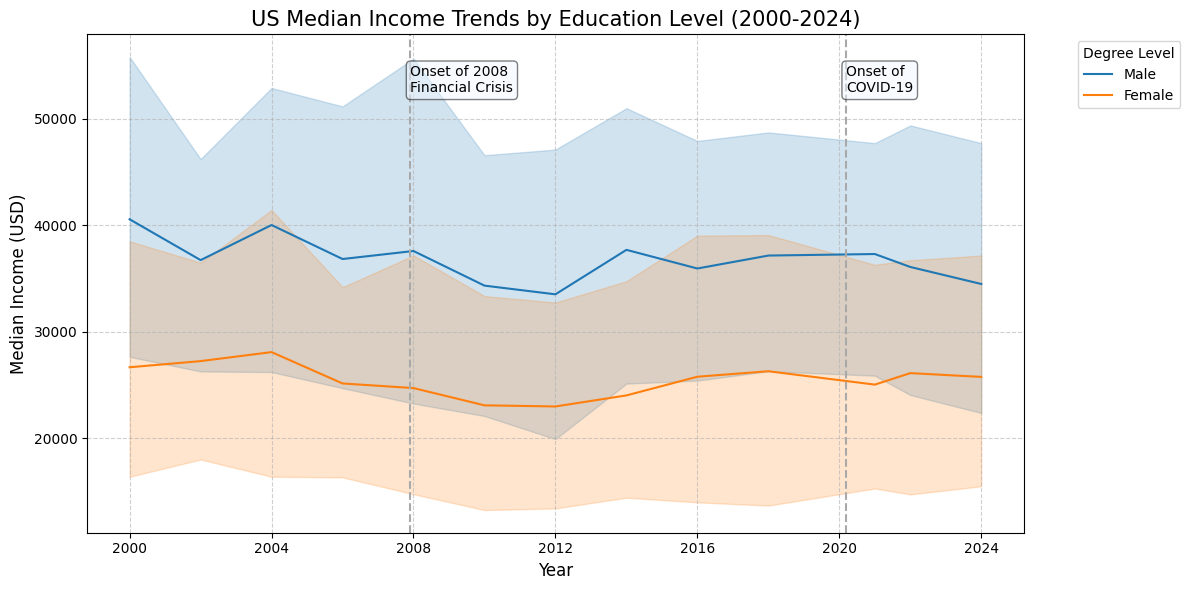

In [0]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=income_plot, x='year', y='median_income', hue='sex')

#plot axes and labels
plt.title('US Median Income Trends by Education Level (2000-2024)', fontsize=15)
plt.ylabel('Median Income (USD)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

#plot key economic dates 
ax = plt.gca()

#get y limit
ymin, ymax = ax.get_ylim()
y_label = ymax * 0.95 #plot near top of y-axis

#plot dates
crisis_date = datetime.datetime.strptime('2007-12-01','%Y-%m-%d')
covid_date = datetime.datetime.strptime('2020-03-11','%Y-%m-%d')

ax.axvline(crisis_date, color='darkgray', linestyle='--')
ax.axvline(covid_date, color='darkgray', linestyle='--')

ax.text(crisis_date, y_label, s="Onset of 2008\nFinancial Crisis", ha= "left", va = "top", fontsize=10,  bbox=dict(boxstyle="round", facecolor='aliceblue', alpha=0.5))
ax.text(covid_date, y_label, s="Onset of\nCOVID-19", ha = "left", va = "top", fontsize=10, bbox=dict(boxstyle="round", facecolor='aliceblue', alpha=0.5))


plt.legend(title='Degree Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

/databricks/python/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/databricks/python/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


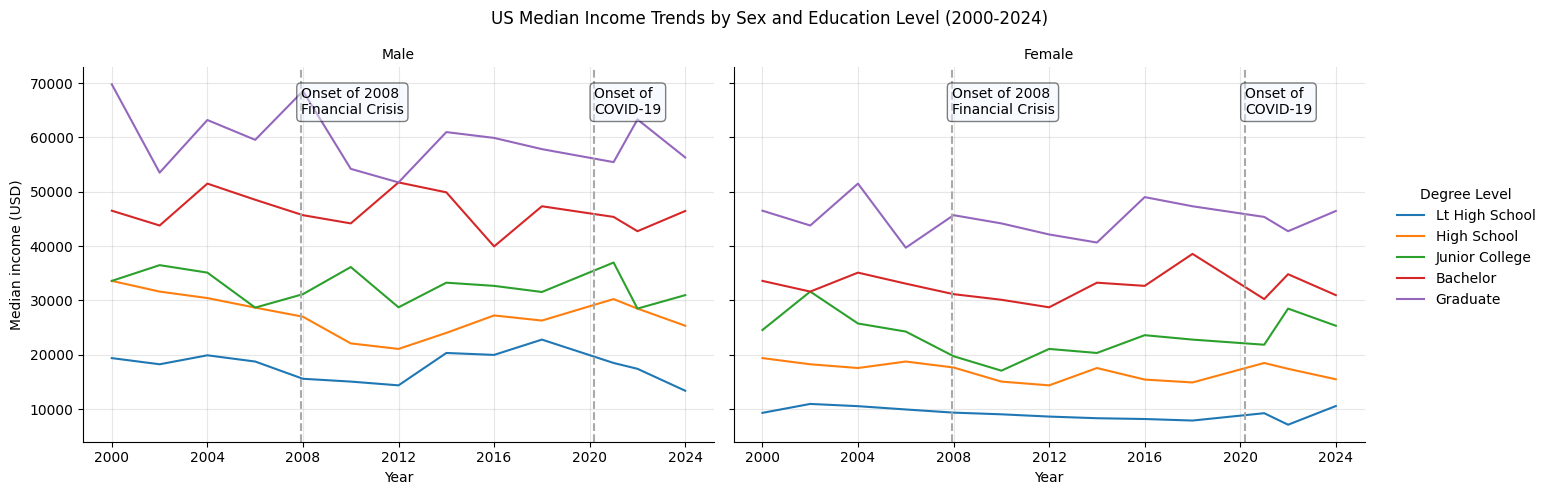

In [0]:
#set legend order
degree_order = ['Lt High School', 'High School', 'Junior College', 'Bachelor', 'Graduate']

#add relevant dates
crisis_date = datetime.datetime.strptime('2007-12-01','%Y-%m-%d')
covid_date = datetime.datetime.strptime('2020-03-11','%Y-%m-%d')

p = sns.relplot(
    data=income_plot,               # pandas version of income_trends
    x='year',              # or 'year' if numeric
    y='median_income',
    hue='degree',
    hue_order=degree_order,
    col='sex',                  # one column per sex: Male, Female
    kind='line',
    height=5,
    aspect=1.4,
)

#plot axes and labels
p.fig.subplots_adjust(top=0.9)
p.fig.suptitle('US Median Income Trends by Sex and Education Level (2000-2024)')
p.set_axis_labels('Year', 'Median income (USD)')
p.set_titles(col_template="{col_name}")

for ax in p.axes.flat:
  #make grid
  ax.grid(True, linestyle = 'solid', alpha=0.3)

  #plot dates
  ymin, ymax = ax.get_ylim()
  y_label = ymax * 0.95 #plot near top of y-axis

  ax.axvline(crisis_date, color='darkgray', linestyle='--')
  ax.axvline(covid_date, color='darkgray', linestyle='--')

  ax.text(crisis_date, y_label, s="Onset of 2008\nFinancial Crisis", ha= "left", va = "top", fontsize=10,  bbox=dict(boxstyle="round", facecolor='aliceblue', alpha=0.5))
  ax.text(covid_date, y_label, s="Onset of\nCOVID-19", ha = "left", va = "top", fontsize=10, bbox=dict(boxstyle="round", facecolor='aliceblue', alpha=0.5))

#make legend
legend = p.legend
legend.set_title("Degree Level")
p.tight_layout()

plt.show()

### analysis typical income by industry per year

In [0]:
industry_income = (
df
.filter(
    (F.year(F.col("year")) >= 2000) & 
    (F.year(F.col("year")) <= 2024))
.filter(
    F.col("conrinc").isNotNull() &  
    F.col("sex").isNotNull() &
    F.col("industry_group").isNotNull() &
    ~F.col('industry_group').isin('Unclassified/No Response') &
    F.col('macro_group').isNotNull() &
     ~F.col('macro_group').isin('Unclassified/No Response'))

.groupBy("year", "macro_group", "industry_group", "sex")
.agg(F.percentile_approx("conrinc", 0.5).alias("median_income"))
.orderBy("year", "macro_group", "industry_group")
)
# Convert to Pandas for plotting
industry_income_plot = industry_income.toPandas()

In [0]:
industry_income_plot.head()

,year,macro_group,industry_group,sex,median_income
0,2000-01-01,Knowledge & Public Services,Business Support & Facility Services,Female,21959.0
1,2000-01-01,Knowledge & Public Services,Business Support & Facility Services,Male,33585.0
2,2000-01-01,Knowledge & Public Services,Education & Health Services,Male,19376.0
3,2000-01-01,Knowledge & Public Services,Education & Health Services,Female,11626.0
4,2000-01-01,Knowledge & Public Services,Government & Defense,Female,24543.0


/databricks/python/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


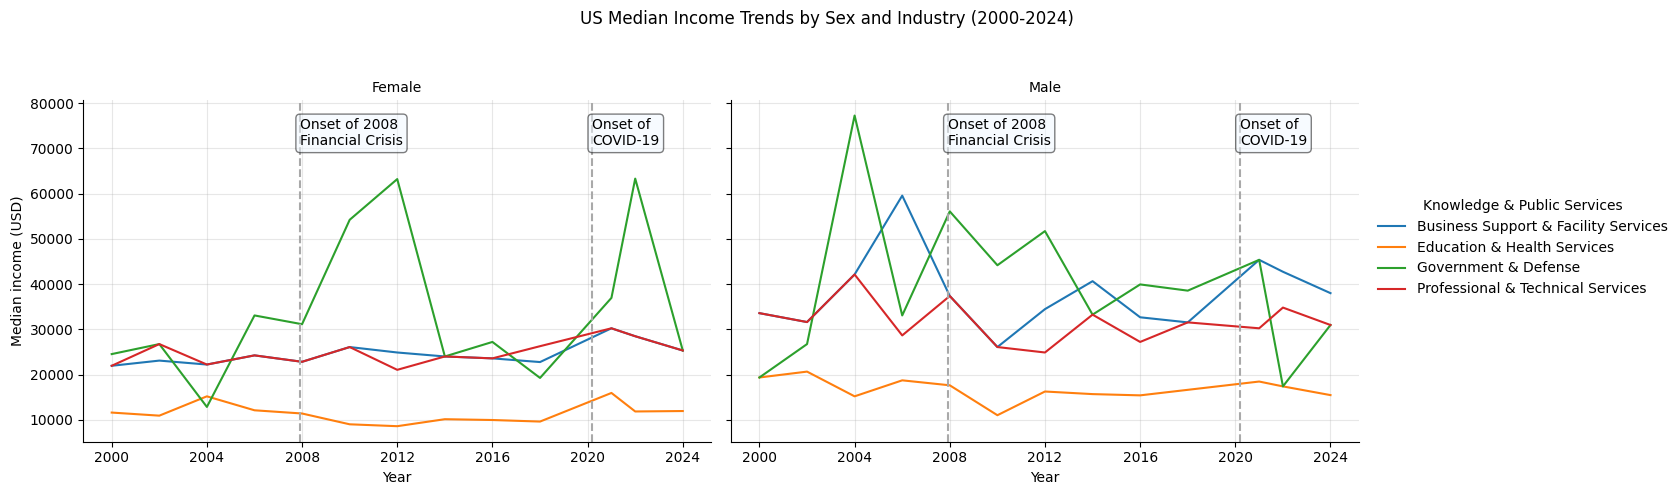

/databricks/python/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 640x480 with 0 Axes>

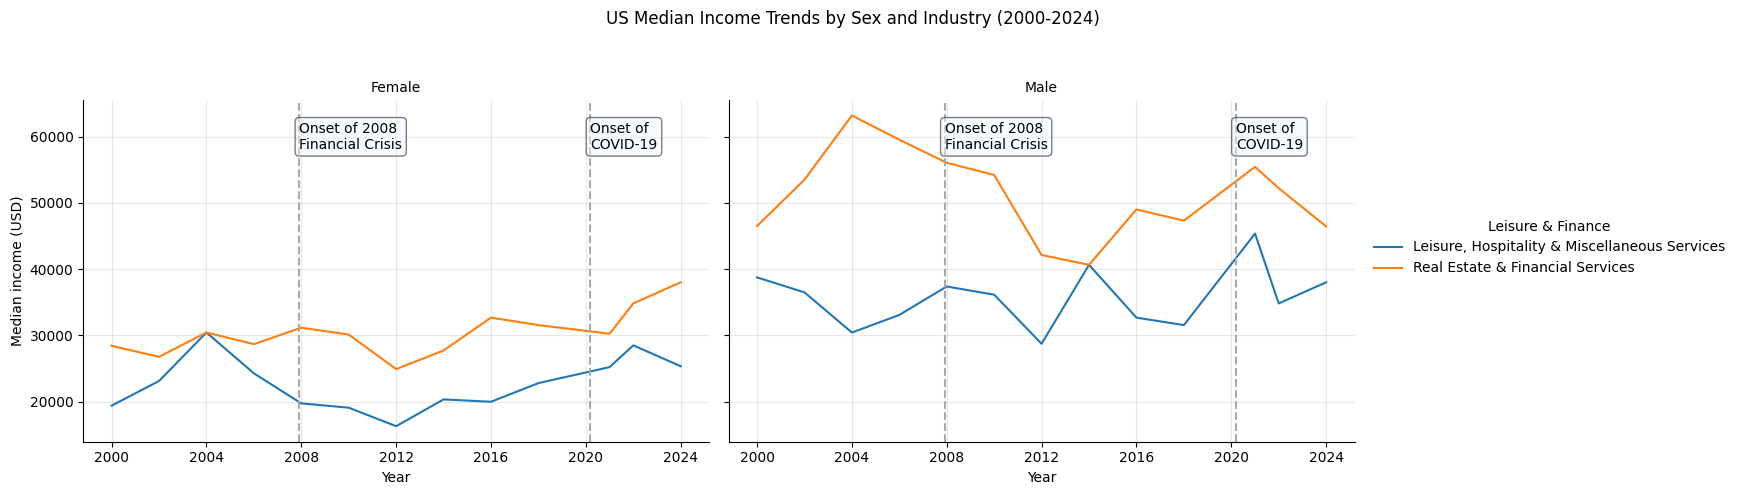

/databricks/python/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 640x480 with 0 Axes>

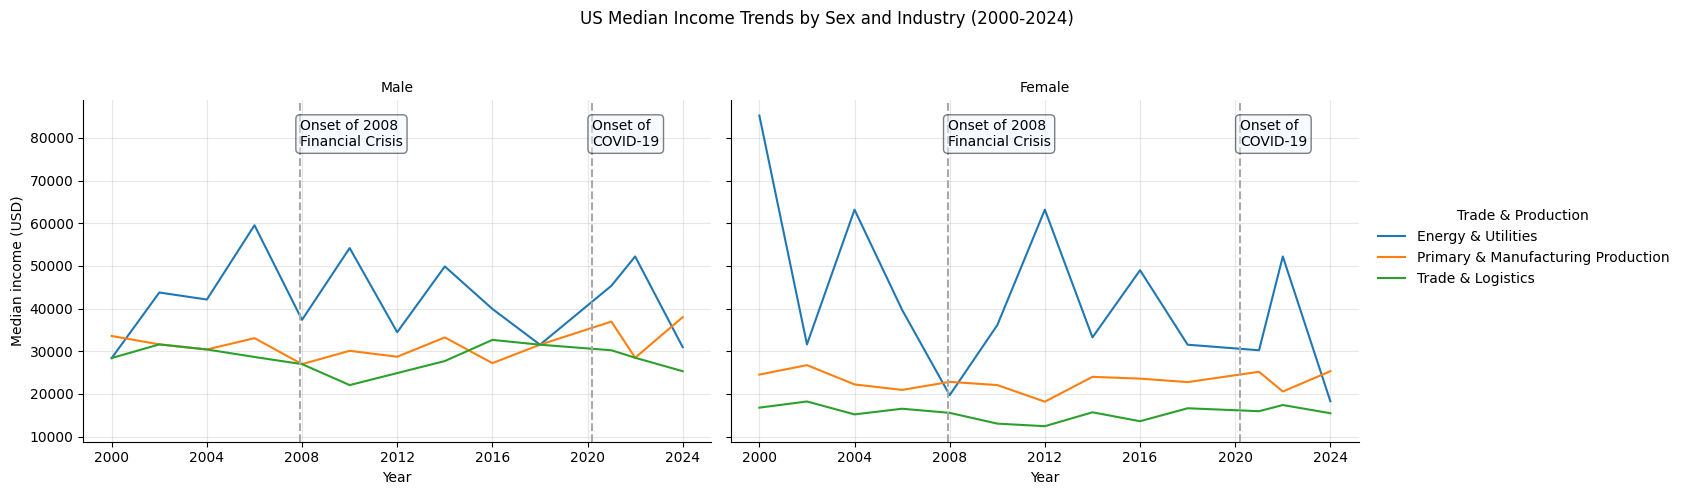

<Figure size 640x480 with 0 Axes>

In [0]:
#add relevant dates
crisis_date = datetime.datetime.strptime('2007-12-01','%Y-%m-%d')
covid_date = datetime.datetime.strptime('2020-03-11','%Y-%m-%d')

macro_groups = industry_income_plot['macro_group'].unique()

# Loop through each macro group - ONE relplot per macro group
for macro in macro_groups:
    # Filter data for THIS macro group only
  macro_data = industry_income_plot[industry_income_plot['macro_group'] == macro]

  p = sns.relplot(
      data=macro_data,               # pandas version of income_trends
      x='year',        
      y='median_income',
      hue='industry_group',
      col='sex',                  # one column per sex: Male, Female
      row = 'macro_group',
      kind='line',
      height=5,
      aspect=1.4,
      #palette='tab10'
  )

  #plot axes and labels
  p.fig.subplots_adjust(top=0.8)
  p.fig.suptitle('US Median Income Trends by Sex and Industry (2000-2024)')
  p.set_axis_labels('Year', 'Median income (USD)')
  p.set_titles(template="{col_name}") #set facet grid title

  for ax in p.axes.flat:
    #make grid
    ax.grid(True, linestyle = 'solid', alpha=0.3)

    #plot dates
    ymin, ymax = ax.get_ylim()
    y_label = ymax * 0.95 #plot near top of y-axis

    ax.axvline(crisis_date, color='darkgray', linestyle='--')
    ax.axvline(covid_date, color='darkgray', linestyle='--')

    ax.text(crisis_date, y_label, s="Onset of 2008\nFinancial Crisis", ha= "left", va = "top", fontsize=10,  bbox=dict(boxstyle="round", facecolor='aliceblue', alpha=0.5))
    ax.text(covid_date, y_label, s="Onset of\nCOVID-19", ha = "left", va = "top", fontsize=10, bbox=dict(boxstyle="round", facecolor='aliceblue', alpha=0.5))

  legend = p._legend
  legend.set_title(f"{macro}")
 
  plt.show()
  plt.savefig(f'{macro}_industry_income.png', dpi=300)

### industry amd job satisfaction

In [0]:
data = apply_gss_industries(data, 'indus10')
data = apply_industry_groups(data, 'industry_name')
data = apply_macro_groups(data, 'industry_group')

In [0]:
data.head()

Row(year=datetime.date(2000, 1, 1), age=26, cohort=datetime.date(1974, 1, 1), sex=1, race=1, ethnic=None, hispanic=1, marital=5, region=3, educ=16, degree=3, dipged=None, income=None, coninc=None, uscitzn=None, wrkstat=1, evwork=None, wrkslf=2, wrkslffam=None, whatslf2=None, indus10=6670, wrkgovt1=None, wrkgovt2=None, occ10=2900, prestg10=43, sei10=57.3, rincome=8, conrinc=9300.0, localnum=4, wksub=1, wksubs=3, wksup=2, wksups=None, paeduc=16, maeduc=16, happy=2, satjob=1, class=3, satfin=3, finalter=3, finrela=4, joblose=4, jobfind=2, getahead=3, richwork=None, unemp=None, union=None, parsol=None, goodlife=None, industry_name='Information', industry_group='Real Estate & Financial Services', macro_group='Leisure & Finance')

In [0]:
wrk_sat = (
data
.filter(
    (F.year(F.col("year")) >= 2000) & 
    (F.year(F.col("year")) <= 2024))
.filter(
    F.col("conrinc").isNotNull() & 
    F.col("industry_group").isNotNull() &
    ~F.col('industry_group').isin('Unclassified/No Response') &
    F.col("satjob").isNotNull() & 
    F.col("satfin").isNotNull() & 
    F.col("finalter").isNotNull() &
    F.col("happy").isNotNull()
)
.groupBy("year", "industry_group")
.agg(
    F.mean(F.col("conrinc")).alias("avg_income"),
    F.mean(F.col("satjob")).alias("avg_satjob"),
    F.mean(F.col("satfin")).alias("avg_satfin"),
    F.mean(F.col("happy")).alias("avg_happy"),
    F.count("*")).alias("n")
.orderBy("year", "industry_group")
)

wrk_sat_ceil = (
  wrk_sat
  .withColumn("avg_income", F.ceil(F.col("avg_income")))
  .withColumn("avg_satjob", F.ceil(F.col("avg_satjob")))
  .withColumn("avg_satfin", F.ceil(F.col("avg_satfin")))
  .withColumn("avg_happy", F.ceil(F.col("avg_happy")))
)
# Convert to Pandas for plotting
wrk_sat_plot = wrk_sat.toPandas()


In [0]:
wrk_sat_plot.head()

,year,industry_group,avg_income,avg_satjob,avg_satfin,avg_happy,count(1)
0,2000-01-01,Business Support & Facility Services,33019.508671,1.745665,2.057803,1.739884,173
1,2000-01-01,Education & Health Services,19594.145161,1.784946,2.118280,1.887097,186
2,2000-01-01,Energy & Utilities,44306.083333,1.750000,1.916667,1.750000,12
3,2000-01-01,Government & Defense,37944.500000,1.625000,2.250000,1.750000,8
4,2000-01-01,"Leisure, Hospitality & Miscellaneous Services",34543.198675,1.701987,1.807947,1.761589,151


In [0]:
wrk_sat_plot.describe()

,avg_income,avg_satjob,avg_satfin,avg_happy,count(1)
count,117.000000,117.000000,117.000000,117.000000,117.000000
mean,39704.536324,1.653172,1.977788,1.843871,150.735043
std,12948.776143,0.182456,0.176772,0.117017,98.763161
min,14043.162791,1.000000,1.250000,1.523810,3.000000
25%,31602.321300,1.559322,1.887179,1.766423,78.000000
50%,37944.500000,1.670807,1.994350,1.827778,161.000000
75%,44379.843750,1.732143,2.090909,1.933333,208.000000
max,82563.400000,2.666667,2.333333,2.109195,443.000000


In [0]:
wrk_sat_plot['industry_group'].unique()

array(['Business Support & Facility Services',
       'Education & Health Services', 'Energy & Utilities',
       'Government & Defense',
       'Leisure, Hospitality & Miscellaneous Services',
       'Primary & Manufacturing Production',
       'Professional & Technical Services',
       'Real Estate & Financial Services', 'Trade & Logistics'],
      dtype=object)

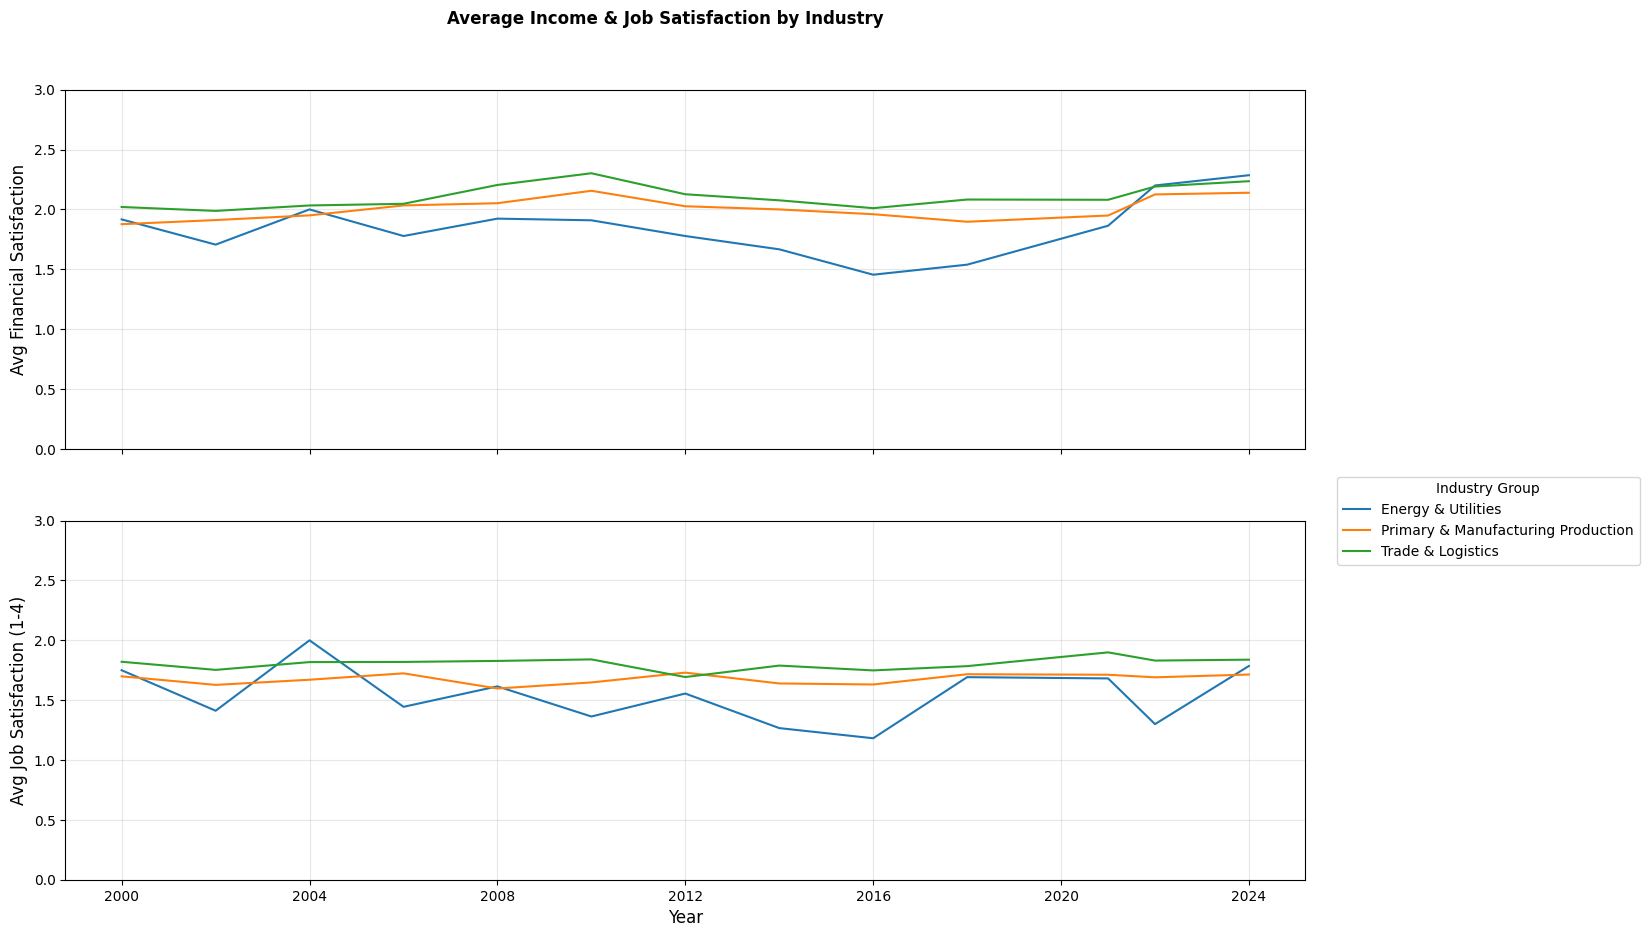

<Figure size 1200x600 with 0 Axes>

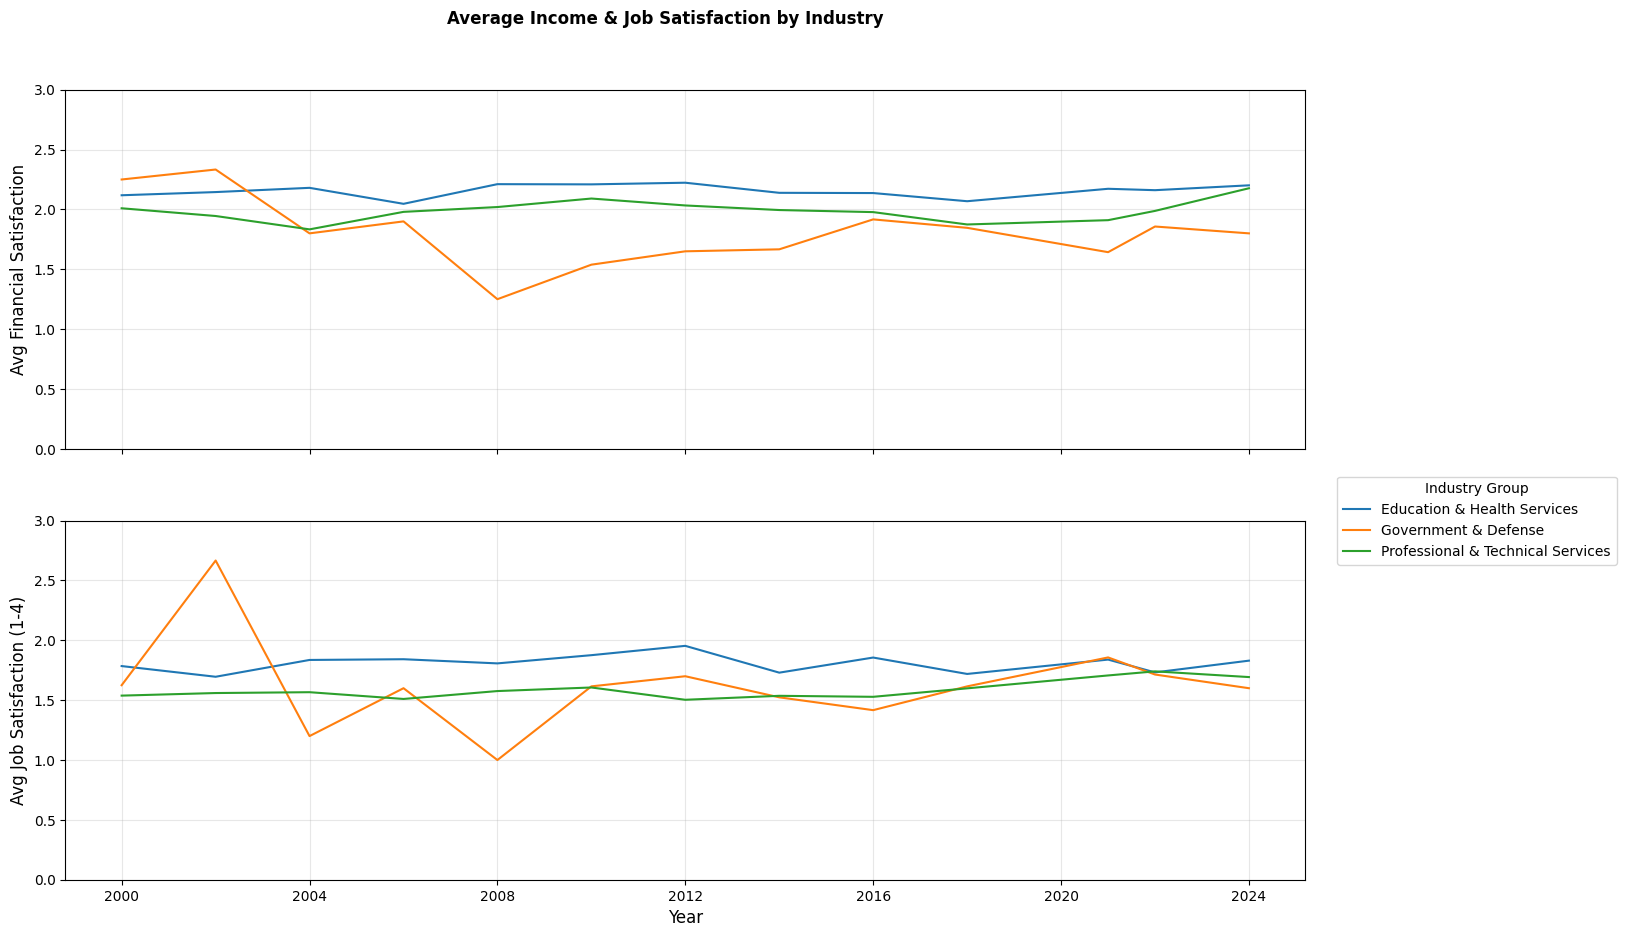

<Figure size 1200x600 with 0 Axes>

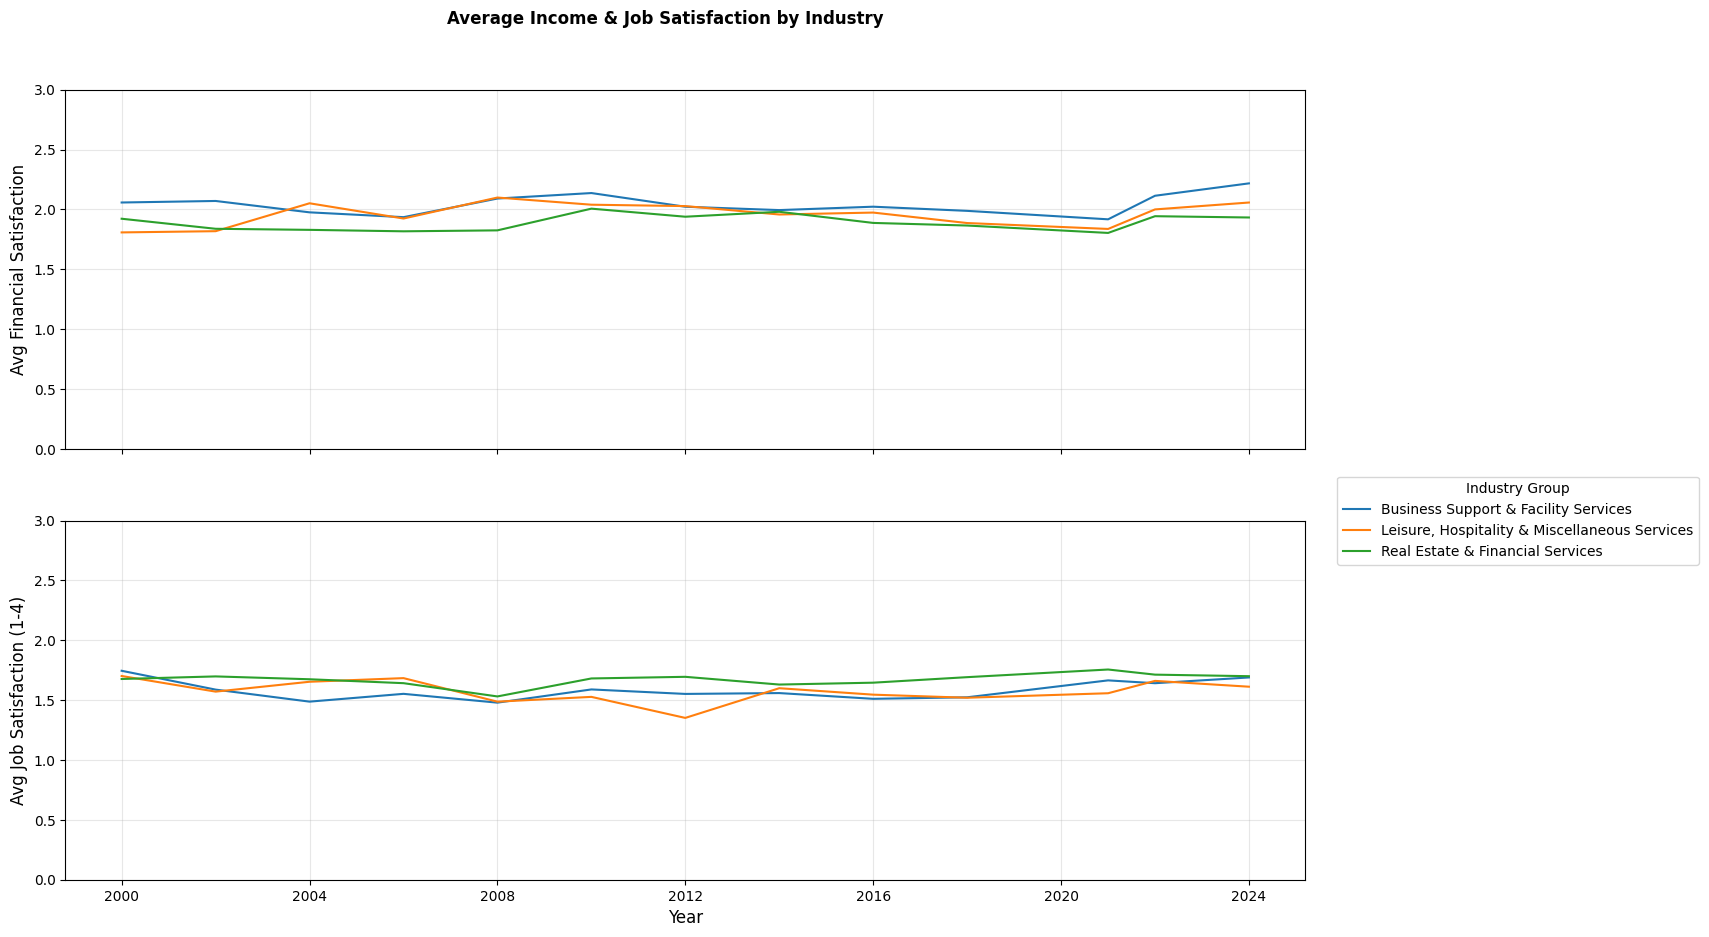

<Figure size 1200x600 with 0 Axes>

In [0]:
industry_groups = {
    "group1": ['Primary & Manufacturing Production', 'Energy & Utilities', 'Trade & Logistics'],
    "group2": ['Education & Health Services', 'Government & Defense', 'Professional & Technical Services'],
    "group3": ['Business Support & Facility Services', 'Real Estate & Financial Services', 'Leisure, Hospitality & Miscellaneous Services']
}

for group, industry in industry_groups.items():
    wrk_sat_plot_group = wrk_sat_plot[wrk_sat_plot['industry_group'].isin(industry_groups[group])]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    plt.figure(figsize=(12, 6))

    sns.lineplot(data = wrk_sat_plot_group, x = "year", y = "avg_satfin", hue = "industry_group", ax = ax1, legend=False)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 3)
    ax1.set_ylabel("Avg Financial Satisfaction", fontsize=12)
    ax1.set_xlabel("Year", fontsize=12)

    sns.lineplot(data = wrk_sat_plot_group, x = "year", y = "avg_satjob", hue = "industry_group", ax = ax2)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 3)
    ax2.set_ylabel("Avg Job Satisfaction (1-4)", fontsize=12)
    ax2.set_xlabel("Year", fontsize=12)
    ax2.legend(title = 'Industry Group', bbox_to_anchor=(1.02, 1), loc = 'center left')
    
    fig.suptitle('Average Income & Job Satisfaction by Industry', fontsize = 12, weight = 'bold')
    fig.subplots_adjust(top=0.9)
    #fig.tight_layout()
    fig.savefig(f'{group}_industry_income.png', bbox_inches='tight')
    fig.show()



### workforce trends by generation

In [0]:
data.select('cohort').distinct().sort('cohort', ascending=True).show()

+----------+
|    cohort|
+----------+
|      NULL|
|1911-01-01|
|1912-01-01|
|1913-01-01|
|1914-01-01|
|1915-01-01|
|1916-01-01|
|1917-01-01|
|1918-01-01|
|1919-01-01|
|1920-01-01|
|1921-01-01|
|1922-01-01|
|1923-01-01|
|1924-01-01|
|1925-01-01|
|1926-01-01|
|1927-01-01|
|1928-01-01|
|1929-01-01|
+----------+
only showing top 20 rows


In [0]:
#get generational data, by cohort year
gen = data.withColumn(
    "generation",
    F.when(F.year(F.col('cohort')) >= 1997, "Gen Z") \
    .when(F.year(F.col('cohort')).between(1965, 1980), "Gen X") \
    .when(F.year(F.col('cohort')).between(1981, 1996), "Millennial") \
    .otherwise("Baby Boomer")) \
    .withColumn("unemployed", F.when(F.col('wrkstat') == 4, 1).otherwise(0)) \
    .withColumn('low_income', F.when(F.col("conrinc") <= 25000, 1).otherwise(0)) #tag low income if conrinc <= 25000 #tag unemployment if wrkstat == 4


gen_summary = gen.groupBy('year', 'generation').agg(
    F.mean('unemployed').alias('unemployment_rate'), 
    F.mean('low_income').alias('low_income_rate'),
    F.percentile_approx('conrinc', 0.5).alias('median_income'),
    F.avg('satjob').alias('avg_satjob'),
    F.count('*').alias('n')) \
    .filter(F.col('n') >= 50)

gen_df = gen.toPandas()
gen_sum_df = gen_summary.toPandas()

In [0]:
gen_sum_df.head()

,year,generation,unemployment_rate,low_income_rate,median_income,avg_satjob,n
0,2000-01-01,Gen X,0.032491,0.481348,21959.0,1.728346,831
1,2000-01-01,Baby Boomer,0.016021,0.245995,33585.0,1.682482,1935
2,2000-01-01,Millennial,0.039216,0.529412,3617.0,2.033333,51
3,2002-01-01,Gen X,0.057860,0.390830,23105.0,1.759036,916
4,2002-01-01,Baby Boomer,0.036041,0.226545,31618.0,1.595745,1748


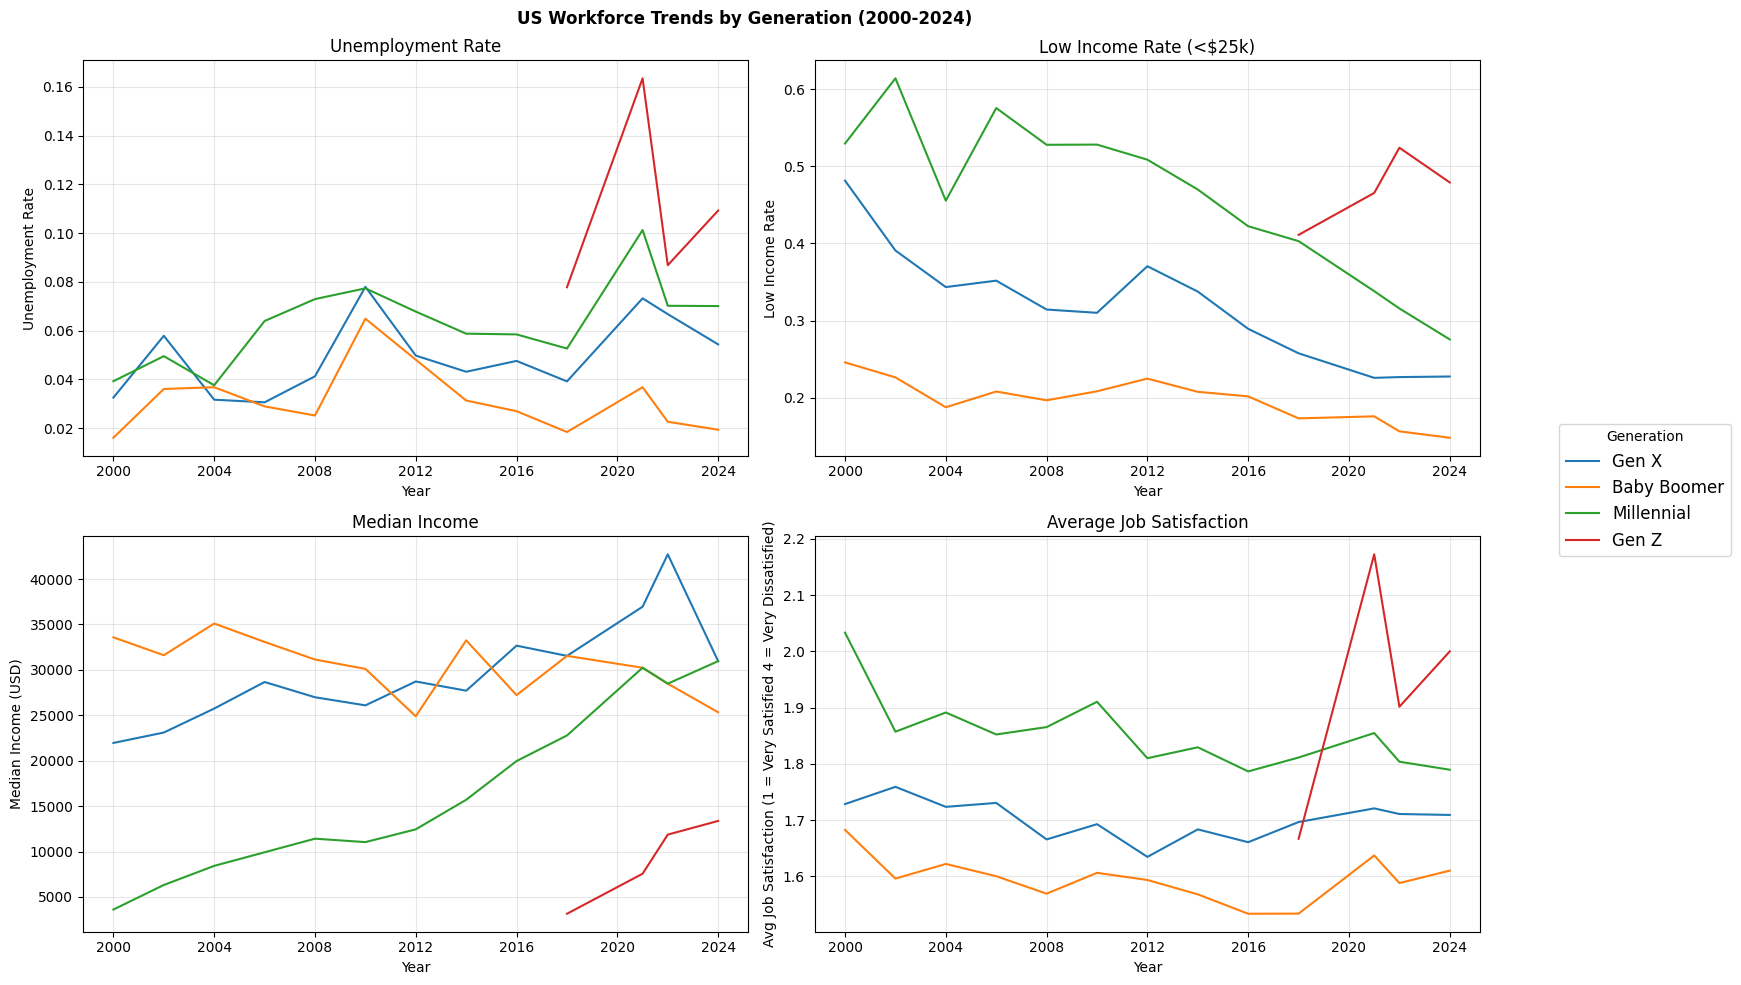

In [0]:
metrics = {'unemployment_rate': ['Unemployment Rate', 'Unemployment Rate'], 
           'low_income_rate':['Low Income Rate (<$25k)', 'Low Income Rate'], 
           'median_income':['Median Income', 'Median Income (USD)'], 
           'avg_satjob': ['Average Job Satisfaction', 'Avg Job Satisfaction (1 = Very Satisfied 4 = Very Dissatisfied)']
           }


fig, axes = plt.subplots(2,2, figsize = (15, 10))

for i, (metric, title) in enumerate(metrics.items()):
  ax = axes[i//2, i%2]
  handles, labels = axes[0,0].get_legend_handles_labels() #get legend labels
  sns.lineplot(data = gen_sum_df, x = "year", y = metric, hue='generation', ax=ax)
  ax.set_title(title[0])
  ax.set_xlabel('Year')
  ax.set_ylabel(title[1])
  ax.grid(True, alpha = 0.3)
  ax.get_legend().remove()

# handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(1.1, 0.5), title='Generation', fontsize = 12)
plt.suptitle('US Workforce Trends by Generation (2000-2024)', fontsize = 12, weight = 'bold')
plt.tight_layout()
#plt.savefig('generational_trends.png')
plt.show()